# Image and mask augmentation with Variopinta

Explore the [Oxford-IIIT Pet dataset](https://robots.ox.ac.uk/~vgg/data/pets/), augment images and segmentation masks together, replay a pair by key, and train a small segmentation model with [PyTorch Lightning](https://api.lightning.ai/docs/pytorch/stable/common/lightning_module.html).

Download this notebook and **Run All** in a fresh Python 3.12 or 3.13 Jupyter kernel with one CUDA GPU. The install cell uses published packages; no repository checkout or companion file is needed. Torchvision downloads approximately **800 MB** of dataset archives and reuses the extracted data on subsequent runs. The pretrained ImageNet backbone is a separate download, also cached. Keep a few GB free for archives, extracted images, and packages.

We start with 128 × 128 images, batch size 16, and nine epochs. This is a demonstration of joint augmentation and training integration, not a speed or competitive accuracy comparison.

In [1]:
%pip install -q variopinta==0.4.4 pytorch-lightning==2.6.1 torchmetrics==1.8.2 torch==2.9.1 torchvision==0.24.1 numpy==2.2.6 matplotlib==3.10.8 pillow==12.1.0

In [2]:
import logging
import time
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import variopinta as vp
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassJaccardIndex
from torchvision.datasets import OxfordIIITPet
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models.segmentation import lraspp_mobilenet_v3_large

SEED = 42
CACHE = Path.home() / ".cache" / "variopinta-oxford-pets"
SIZE, BATCH_SIZE, WORKERS, EPOCHS = 128, 16, 4, 9

if not torch.cuda.is_available():
    raise RuntimeError("Select a CUDA GPU kernel/runtime to run this notebook.")
CACHE.mkdir(parents=True, exist_ok=True)
torch.hub.set_dir(str(CACHE / "weights"))
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
pl.seed_everything(SEED, workers=True)
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
print(
    f"Variopinta {version('variopinta')} · Lightning {pl.__version__} · Torch {torch.__version__}"
)
print("GPU:", torch.cuda.get_device_name(0))

Variopinta 0.4.4 · Lightning 2.6.1 · Torch 2.9.1+cu128
GPU: NVIDIA GeForce RTX 3090


## Load the pairs

Torchvision's [public dataset interface](https://docs.pytorch.org/vision/0.24/generated/torchvision.datasets.OxfordIIITPet.html) returns a PIL RGB image and a segmentation trimap. It handles downloading, extraction, and cache reuse. A fixed seeded permutation divides `trainval` into 80% training and 20% validation. The official `test` split stays reserved for final evaluation.

The downloaded annotation README defines **1 = pet, 2 = background, 3 = boundary**. A four-entry lookup table converts these to **pet = 1, background = 0, boundary = 255**. Boundary pixels are ignored by both loss and IoU. Masks remain HW `uint8`: their class values are never normalized or converted to RGB.

In [3]:
trainval = OxfordIIITPet(CACHE, split="trainval", target_types="segmentation", download=True)
test_data = OxfordIIITPet(CACHE, split="test", target_types="segmentation", download=True)
order = np.random.default_rng(SEED).permutation(len(trainval)).tolist()
cut = int(0.8 * len(order))
train_indices, valid_indices = order[:cut], order[cut:]
assert set(train_indices).isdisjoint(valid_indices)
assert sorted(train_indices + valid_indices) == list(range(len(trainval)))

annotation_readme = (CACHE / "oxford-iiit-pet" / "annotations" / "README").read_text()
label_lines = [
    line.strip()
    for line in annotation_readme.splitlines()
    if any(label in line for label in ("Foreground", "Background", "Not classified"))
]
print("Annotation README:", " / ".join(label_lines))
LABEL_MAP = np.array([255, 1, 0, 255], dtype=np.uint8)
print(
    f"{len(train_indices):,} training · {len(valid_indices):,} validation · {len(test_data):,} held-out test pairs"
)

pairs = []
for index in train_indices[:3]:
    pil_image, pil_mask = trainval[index]
    rgb, raw = np.asarray(pil_image), np.asarray(pil_mask)
    assert raw.ndim == 2 and raw.dtype == np.uint8
    assert set(np.unique(raw)) <= {1, 2, 3}
    mask = LABEL_MAP[raw]
    assert rgb.shape[:2] == mask.shape and mask.dtype == np.uint8
    assert np.array_equal(mask == 1, raw == 1)
    assert np.array_equal(mask == 0, raw == 2)
    assert np.array_equal(mask == 255, raw == 3)
    pairs.append((rgb, mask))

Annotation README: Pixel Annotations: 1: Foreground 2:Background 3: Not classified
2,944 training · 736 validation · 3,669 held-out test pairs


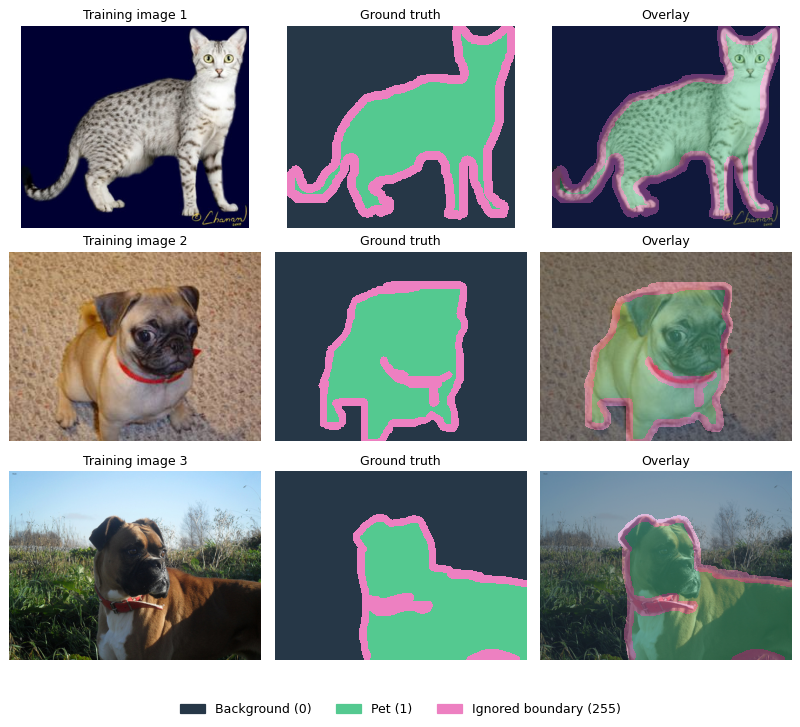

In [4]:
def grid(panels, columns=3):
    rows = (len(panels) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 3, rows * 2.7), squeeze=False)
    colors = ListedColormap(["#263747", "#54c990", "#ed80c1"])
    for ax, (rgb, mask, title) in zip(axes.flat, panels, strict=False):
        if rgb is not None:
            ax.imshow(rgb)
        if mask is not None:
            display_mask = np.where(np.asarray(mask) == 255, 2, mask)
            ax.imshow(
                display_mask,
                cmap=colors,
                vmin=0,
                vmax=2,
                interpolation="nearest",
                alpha=0.45 if rgb is not None else 1.0,
            )
        ax.set_title(title)
    for ax in axes.flat:
        ax.axis("off")
    fig.legend(
        handles=[
            Patch(color=colors(i), label=name)
            for i, name in enumerate(("Background (0)", "Pet (1)", "Ignored boundary (255)"))
        ],
        loc="lower center",
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    plt.show()


panels = []
for i, (rgb, mask) in enumerate(pairs):
    panels.extend(
        [
            (rgb, None, f"Training image {i + 1}"),
            (None, mask, "Ground truth"),
            (rgb, mask, "Overlay"),
        ]
    )
grid(panels)

## Transform image and mask together

Bind explicit `vp.Image` and `vp.Mask(fill=255)` array targets. Variopinta samples geometry once for the pair: resize, crop, and flip keep the mask aligned with the image. Images use bilinear interpolation with antialiasing; masks use nearest interpolation, preserving class labels. The mask's fill value marks any constant border as ignored.

Color jitter changes only the image. These visual demonstrations run before normalization.

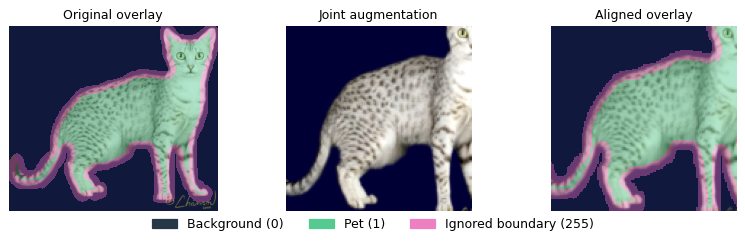

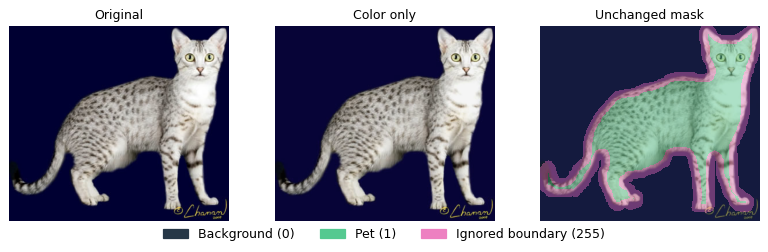

In [5]:
image_target = vp.Image(carrier=vp.Array(), outputs=vp.ReturnArray(name="array"), name="image")
mask_target = vp.Mask(
    carrier=vp.Array(), outputs=vp.ReturnArray(name="array"), name="mask", fill=255
)
rgb, mask = pairs[0]
reference = vp.Pipeline(
    [
        vp.Resize(SIZE + 32, SIZE + 32, interpolation=vp.Interpolation.BILINEAR, antialias=True),
        vp.RandomCrop(SIZE, SIZE),
        vp.HorizontalFlip(p=0.5),
        vp.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    ],
    seed=SEED,
    targets=(image_target, mask_target),
)
compiled = reference.compile()
first = compiled(image=image_target.bind(rgb), mask=mask_target.bind(mask), key=17)
assert first.image.array.shape == (SIZE, SIZE, 3)
assert first.mask.array.shape == (SIZE, SIZE)
assert first.mask.array.dtype == np.uint8 and set(np.unique(first.mask.array)) <= {0, 1, 255}
grid(
    [
        (rgb, mask, "Original overlay"),
        (first.image.array, None, "Joint augmentation"),
        (first.image.array, first.mask.array, "Aligned overlay"),
    ]
)

color_only = vp.Pipeline(
    [vp.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02)],
    seed=SEED,
    targets=(image_target, mask_target),
).compile()
colored = color_only(image=image_target.bind(rgb), mask=mask_target.bind(mask), key=17)
assert np.array_equal(colored.mask.array, mask)
grid(
    [
        (rgb, None, "Original"),
        (colored.image.array, None, "Color only"),
        (colored.image.array, colored.mask.array, "Unchanged mask"),
    ]
)

### Compare geometry operations

Apply each operation separately to the same dog image and mask. Every panel uses a transparent mask overlay so you can follow the pet's outline. Rotation and perspective are visual demonstrations; the training policy below uses random resized crop and horizontal flip. Pink wedges in the rotated result show how `Mask(fill=255)` marks newly exposed borders as ignored.

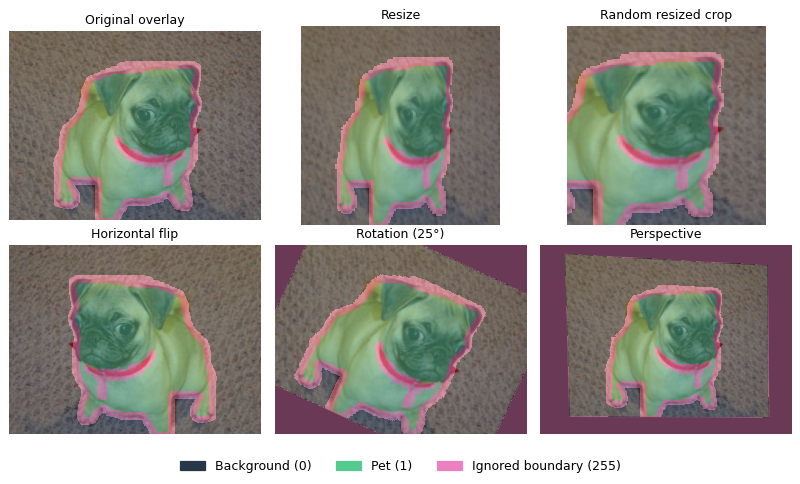

In [6]:
demo_rgb, demo_mask = pairs[1]
geometry_demos = {
    "Resize": vp.Resize(SIZE, SIZE, antialias=True),
    "Random resized crop": vp.RandomResizedCrop(SIZE, SIZE, scale=(0.45, 0.7), antialias=True),
    "Horizontal flip": vp.HorizontalFlip(p=1.0),
    "Rotation (25°)": vp.RandomRotation(degrees=(25.0, 25.0)),
    "Perspective": vp.Perspective(scale=0.15),
}
geometry_panels = [(demo_rgb, demo_mask, "Original overlay")]
for title, transform in geometry_demos.items():
    demo_reference = vp.Pipeline([transform], seed=SEED, targets=(image_target, mask_target))
    demo_pipeline = demo_reference.compile()
    result = demo_pipeline(
        image=image_target.bind(demo_rgb), mask=mask_target.bind(demo_mask), key=17
    )
    reference_result = demo_reference(
        image=image_target.bind(demo_rgb), mask=mask_target.bind(demo_mask), key=17
    )
    assert result.image.array.shape[:2] == result.mask.array.shape
    assert result.mask.array.dtype == np.uint8
    assert set(np.unique(result.mask.array)) <= {0, 1, 255}
    assert np.array_equal(result.image.array, reference_result.image.array)
    assert np.array_equal(result.mask.array, reference_result.mask.array)
    geometry_panels.append((result.image.array, result.mask.array, title))
grid(geometry_panels)

### One pair, several keys

Now combine resize, random crop, horizontal flip, and modest color jitter using the earlier compiled pipeline. Changing the key produces different augmentations of the same pair. Compare the RGB images with the overlays beneath them: each mask follows its image's crop and flip.

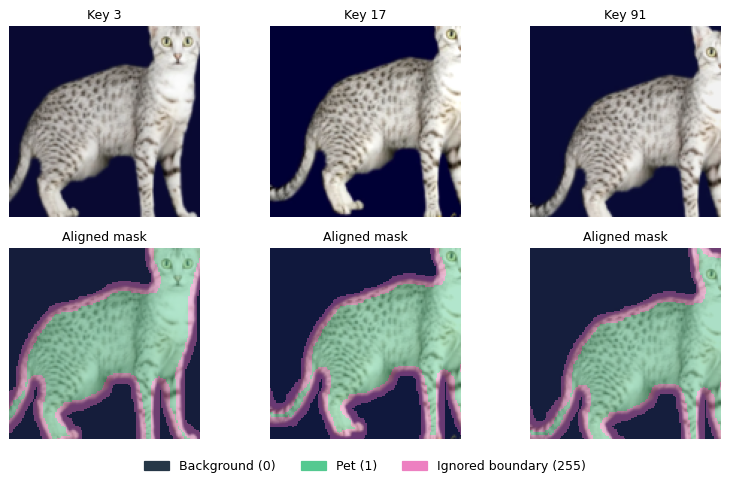

In [7]:
keys = (3, 17, 91)
variants = [
    compiled(image=image_target.bind(rgb), mask=mask_target.bind(mask), key=key) for key in keys
]
key_panels = [
    (result.image.array, None, f"Key {key}") for key, result in zip(keys, variants, strict=True)
]
key_panels.extend((result.image.array, result.mask.array, "Aligned mask") for result in variants)
grid(key_panels)

## Replay and inspect

Repeat the same input pair with the same seed and key after unrelated calls. Both outputs must match exactly. Reference and compiled execution must also agree. Exact replay is scoped to the same inputs, pipeline, release, build, and execution environment; it is not guaranteed across releases or platforms.

`explain()` describes a **static execution plan**, not a profiler or a trace of the sampled augmentation. The excerpt below shows how the compiled plan handles its first image operation.

In [8]:
for other_rgb, other_mask in pairs[1:]:
    compiled(image=image_target.bind(other_rgb), mask=mask_target.bind(other_mask), key=91)
replayed = compiled(image=image_target.bind(rgb), mask=mask_target.bind(mask), key=17)
expected = reference(image=image_target.bind(rgb), mask=mask_target.bind(mask), key=17)
for result in (replayed, expected):
    assert np.array_equal(first.image.array, result.image.array)
    assert np.array_equal(first.mask.array, result.mask.array)
print("Paired keyed replay and reference/compiled equality passed.")
plan = compiled.explain()
print(
    plan["mode"],
    {name: plan["steps"][0][name] for name in ("input_materialization", "kernel_form")},
)

Paired keyed replay and reference/compiled equality passed.
compiled {'input_materialization': 'borrowed-input', 'kernel_form': 'borrowed-to-owned'}


## Prepare training tensors and epoch keys

The next cell writes one small importable module for persistent `spawn` workers. The Dataset adapter decodes through torchvision, remaps labels, calls Variopinta, and converts the augmented mask to `torch.long` for cross entropy. Variopinta owns all image/mask transforms.

A request carries `(epoch, subset_position)`. The adapter looks up the **original dataset index** and uses `epoch * len(trainval) + original_index` as its training key. Subsetting or reordering preserves sample identity. Every training sample occurs once per epoch, and validation/test keys remain fixed. Lightning advances the sampler epoch, so persistent workers need no mutable epoch state.

In [7]:
%%writefile oxford_pets_dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, Sampler


class AugmentedPets(Dataset):
    def __init__(self, dataset, indices, pipeline, label_map, training=False):
        self.dataset, self.indices = dataset, list(indices)
        self.pipeline, self.label_map, self.training = pipeline, label_map, training
        self.image, self.mask = pipeline.targets

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, request):
        epoch, position = request if isinstance(request, tuple) else (0, request)
        index = self.indices[position]
        image, mask = self.dataset[index]
        key = epoch * len(self.dataset) + index if self.training else index
        result = self.pipeline(
            image=self.image.bind(np.asarray(image)),
            mask=self.mask.bind(self.label_map[np.asarray(mask)]),
            key=key,
        )
        return result.image.tensor, result.mask.tensor.long()


class EpochSampler(Sampler):
    def __init__(self, indices, seed):
        self.indices, self.seed, self.epoch = list(indices), seed, 0

    def __len__(self):
        return len(self.indices)

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = torch.Generator().manual_seed(self.seed + self.epoch)
        order = torch.randperm(len(self.indices), generator=rng).tolist()
        return iter((self.epoch, self.indices[i]) for i in order)

Overwriting oxford_pets_dataset.py


In [8]:
from oxford_pets_dataset import AugmentedPets, EpochSampler

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
image_tensor = vp.Image(carrier=vp.Array(), outputs=vp.ReturnTensor(name="tensor"), name="image")
mask_tensor = vp.Mask(
    carrier=vp.Array(), outputs=vp.ReturnTensor(name="tensor"), name="mask", fill=255
)
train_pipeline = vp.Pipeline(
    [
        vp.RandomResizedCrop(
            SIZE, SIZE, scale=(0.65, 1.0), interpolation=vp.Interpolation.BILINEAR, antialias=True
        ),
        vp.HorizontalFlip(p=0.5),
        vp.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
        vp.Normalize(mean=MEAN, std=STD),
    ],
    seed=SEED,
    targets=(image_tensor, mask_tensor),
).compile()
eval_pipeline = vp.Pipeline(
    [
        vp.Resize(SIZE, SIZE, interpolation=vp.Interpolation.BILINEAR, antialias=True),
        vp.Normalize(mean=MEAN, std=STD),
    ],
    seed=SEED,
    targets=(image_tensor, mask_tensor),
).compile()
train_ds = AugmentedPets(trainval, train_indices, train_pipeline, LABEL_MAP, training=True)
valid_ds = AugmentedPets(trainval, valid_indices, eval_pipeline, LABEL_MAP)
test_ds = AugmentedPets(test_data, range(len(test_data)), eval_pipeline, LABEL_MAP)

pil_image, pil_mask = trainval[train_indices[0]]
tensors = train_pipeline(
    image=image_tensor.bind(np.asarray(pil_image)),
    mask=mask_tensor.bind(LABEL_MAP[np.asarray(pil_mask)]),
    key=train_indices[0],
)
x, y = tensors.image.tensor, tensors.mask.tensor
assert x.shape == (3, SIZE, SIZE) and x.dtype == torch.float32 and x.is_contiguous()
assert y.shape == (SIZE, SIZE) and y.dtype == torch.uint8 and y.is_contiguous()
assert set(y.unique().tolist()) <= {0, 1, 255}
adapted_x, adapted_y = train_ds[(0, 0)]
assert torch.equal(adapted_x, x) and torch.equal(adapted_y, y.long())
assert adapted_y.dtype == torch.long and adapted_y.is_contiguous()
reordered = AugmentedPets(
    trainval, train_indices[:3][::-1], train_pipeline, LABEL_MAP, training=True
)
assert all(torch.equal(a, b) for a, b in zip(train_ds[(2, 0)], reordered[(2, 2)], strict=True))
assert all(torch.equal(a, b) for a, b in zip(valid_ds[(0, 0)], valid_ds[(7, 0)], strict=True))
print(
    f"Pipeline: image {tuple(x.shape)} {x.dtype}, mask {tuple(y.shape)} {y.dtype}; loss labels {adapted_y.dtype}"
)

Pipeline: image (3, 128, 128) torch.float32, mask (128, 128) torch.uint8; loss labels torch.int64


Build pipelines before starting the loaders. Each loader uses four persistent `spawn` workers and pinned CPU memory. Standard pickle transfers the compiled pipeline; Lightning moves collated batches to the GPU.

Before training, compare a few worker results with direct Dataset calls for the same epoch and index requests. The sampler visits every position exactly once.

In [9]:
train_sampler = EpochSampler(range(len(train_ds)), SEED)
loader_options = dict(batch_size=BATCH_SIZE, num_workers=WORKERS, pin_memory=True)
if WORKERS:
    loader_options.update(multiprocessing_context="spawn", persistent_workers=True)
train_loader = DataLoader(train_ds, sampler=train_sampler, **loader_options)
valid_loader = DataLoader(valid_ds, shuffle=False, **loader_options)
test_loader = DataLoader(test_ds, shuffle=False, **loader_options)

for epoch in (0, 1):
    train_sampler.set_epoch(epoch)
    requests = list(train_sampler)
    assert sorted(position for _, position in requests) == list(range(len(train_ds)))
    assert all(request_epoch == epoch for request_epoch, _ in requests)
    worker_images, worker_masks = next(iter(train_loader))
    assert worker_images.shape[1:] == (3, SIZE, SIZE) and worker_images.dtype == torch.float32
    assert worker_masks.shape[1:] == (SIZE, SIZE) and worker_masks.dtype == torch.long
    assert worker_images.is_contiguous() and worker_masks.is_contiguous()
    assert set(worker_masks.unique().tolist()) <= {0, 1, 255}
    for position, request in enumerate(requests[:3]):
        direct_image, direct_mask = train_ds[request]
        assert torch.equal(worker_images[position], direct_image)
        assert torch.equal(worker_masks[position], direct_mask)
train_sampler.set_epoch(0)
print(f"Worker/direct equality passed at epochs 0 and 1 · {WORKERS} workers per loader")

Worker/direct equality passed at epochs 0 and 1 · 4 workers per loader


## Train with Lightning

Torchvision's [LR-ASPP MobileNetV3](https://docs.pytorch.org/vision/0.24/models/generated/torchvision.models.segmentation.lraspp_mobilenet_v3_large.html) provides the complete segmentation model. `weights=None` starts a new two-class segmentation head; the explicit ImageNet weight enum initializes the backbone. We fine-tune the whole model with AdamW (`lr=0.001`, weight decay `0.01`), without a scheduler.

Cross entropy and [TorchMetrics multiclass Jaccard/IoU](https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html) both ignore label 255. We report the mean of background and pet IoU over all valid pixels in each evaluation epoch. Separate validation and test metric instances prevent state mixing. Lightning handles device transfer, optimization, loss aggregation, and metric resets.

In [10]:
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)
labels = torch.tensor([[[0, 1], [255, 1]]])
logits = torch.tensor([[[[3.0, -2.0], [4.0, 1.0]], [[-1.0, 2.0], [-4.0, 3.0]]]])
valid_pixels = labels != 255
changed = logits.clone()
changed[:, :, 1, 0] = torch.tensor([[-100.0, 100.0]])
filtered_loss = torch.nn.functional.cross_entropy(
    logits.permute(0, 2, 3, 1)[valid_pixels], labels[valid_pixels]
)
assert torch.allclose(loss_fn(logits, labels), filtered_loss)
assert torch.equal(loss_fn(logits, labels), loss_fn(changed, labels))
iou = MulticlassJaccardIndex(num_classes=2, average="macro", ignore_index=255)
iou_original = iou(logits, labels)
iou.reset()
iou_changed = iou(changed, labels)
iou.reset()
iou_filtered = iou(logits.argmax(1)[valid_pixels], labels[valid_pixels])
assert torch.equal(iou_original, iou_changed) and torch.equal(iou_original, iou_filtered)
print("Loss and mean IoU exclude ignored pixels.")

Loss and mean IoU exclude ignored pixels.


In [11]:
class PetSegmenter(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = lraspp_mobilenet_v3_large(
            weights=None,
            num_classes=2,
            weights_backbone=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
        )
        self.loss = torch.nn.CrossEntropyLoss(ignore_index=255)
        self.valid_iou = MulticlassJaccardIndex(num_classes=2, average="macro", ignore_index=255)
        self.test_iou = MulticlassJaccardIndex(num_classes=2, average="macro", ignore_index=255)
        self.history = []

    def forward(self, images):
        return self.model(images)["out"]

    def on_train_epoch_start(self):
        assert self.trainer.train_dataloader.sampler.epoch == self.current_epoch

    def training_step(self, batch, batch_idx):
        images, masks = batch
        loss = self.loss(self(images), masks)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        self.log("valid_loss", self.loss(logits, masks), on_step=False, on_epoch=True)
        self.valid_iou.update(logits, masks)
        self.log("valid_iou", self.valid_iou, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        images, masks = batch
        self.test_iou.update(self(images), masks)
        self.log("test_iou", self.test_iou, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=0.001, weight_decay=0.01)

    def on_train_epoch_end(self):
        metrics = {
            name: self.trainer.callback_metrics[name].item()
            for name in ("train_loss", "valid_loss", "valid_iou")
        }
        assert all(np.isfinite(value) for value in metrics.values())
        self.history.append(metrics)
        print(
            f"Epoch {self.current_epoch + 1}: train loss {metrics['train_loss']:.3f}, "
            f"valid loss {metrics['valid_loss']:.3f}, mean IoU {metrics['valid_iou']:.1%}"
        )

In [12]:
pl.seed_everything(SEED, workers=True)
segmenter = PetSegmenter()
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
    enable_model_summary=False,
    num_sanity_val_steps=0,
)
started = time.perf_counter()
trainer.fit(segmenter, train_loader, valid_loader)
assert len(segmenter.history) == EPOCHS and train_sampler.epoch == EPOCHS - 1
print(f"Completed {EPOCHS} epochs in {(time.perf_counter() - started) / 60:.1f} minutes.")

Epoch 1: train loss 0.172, valid loss 0.169, mean IoU 88.1%
Epoch 2: train loss 0.112, valid loss 0.176, mean IoU 87.8%
Epoch 3: train loss 0.090, valid loss 0.126, mean IoU 90.6%
Epoch 4: train loss 0.087, valid loss 0.129, mean IoU 90.2%
Epoch 5: train loss 0.080, valid loss 0.100, mean IoU 92.4%
Epoch 6: train loss 0.075, valid loss 0.097, mean IoU 92.6%
Epoch 7: train loss 0.065, valid loss 0.118, mean IoU 91.4%
Epoch 8: train loss 0.067, valid loss 0.108, mean IoU 91.7%
Epoch 9: train loss 0.068, valid loss 0.112, mean IoU 92.0%
Completed 9 epochs in 0.6 minutes.


## Inspect the result

Plot epoch-average losses and validation mean IoU. Then evaluate the held-out official test split **once**, using deterministic resize and normalization. The example predicts foreground pet versus background; it does not predict breed or cat versus dog.

In the prediction grid, undo normalization only for image display. Ground-truth and predicted masks overlay the test image at 45% opacity so their alignment is visible. Ground-truth boundaries stay pink to distinguish ignored pixels from background; predicted masks contain only the two model classes. Small details and uncertain edges are difficult at 128 × 128. The result illustrates the working augmentation and tensor-delivery path, not a segmentation accuracy target.

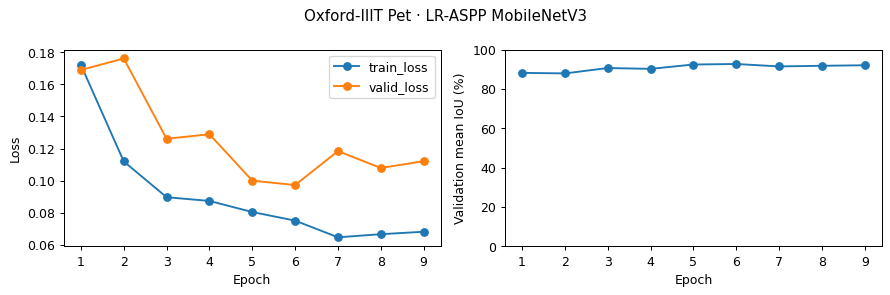

Held-out test mean IoU: 93.1%


In [13]:
epochs = range(1, len(segmenter.history) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
for name in ("train_loss", "valid_loss"):
    axes[0].plot(epochs, [row[name] for row in segmenter.history], "o-", label=name)
axes[0].set(xlabel="Epoch", ylabel="Loss")
axes[0].legend()
axes[1].plot(epochs, [100 * row["valid_iou"] for row in segmenter.history], "o-")
axes[1].set(xlabel="Epoch", ylabel="Validation mean IoU (%)", ylim=(0, 100))
for ax in axes:
    ax.set_xticks(list(epochs))
fig.suptitle("Oxford-IIIT Pet · LR-ASPP MobileNetV3")
fig.tight_layout()
plt.show()

results = trainer.test(segmenter, dataloaders=test_loader, verbose=False)
assert np.isfinite(results[0]["test_iou"])
print(f"Held-out test mean IoU: {results[0]['test_iou']:.1%}")

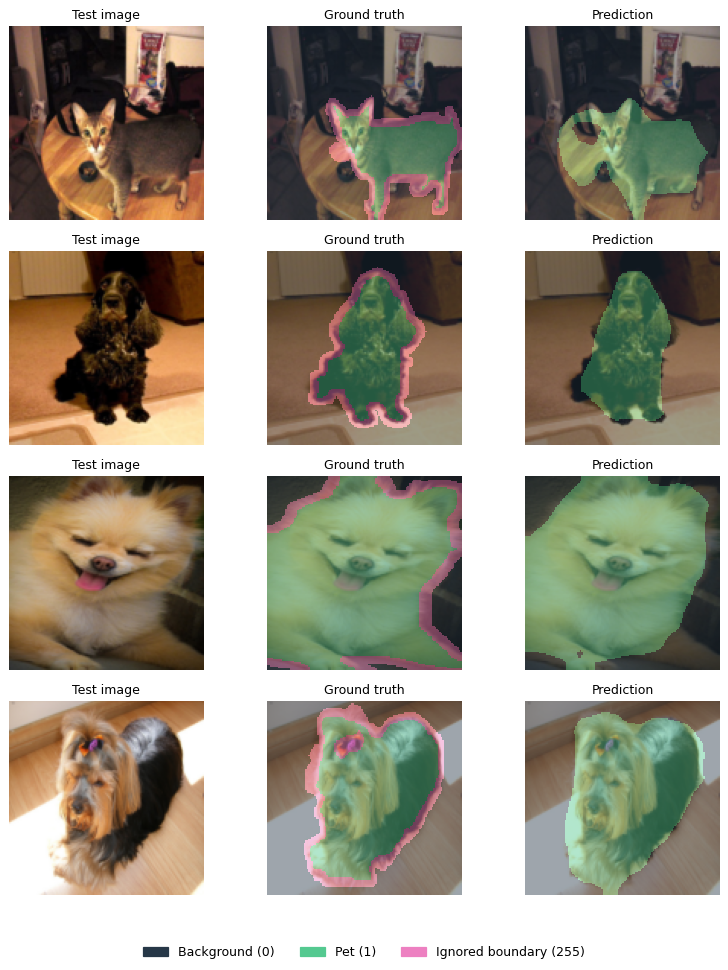

In [14]:
samples = [test_ds[i] for i in np.linspace(0, len(test_ds) - 1, 4, dtype=int)]
images = torch.stack([image for image, _ in samples])
segmenter.eval()
with torch.inference_mode():
    predictions = segmenter(images.to(segmenter.device)).argmax(1).cpu().numpy()
rgb_images = (
    (images.permute(0, 2, 3, 1) * torch.tensor(STD) + torch.tensor(MEAN)).clamp(0, 1).numpy()
)
panels = []
for rgb_image, (_, truth), prediction in zip(rgb_images, samples, predictions, strict=True):
    panels.extend(
        [
            (rgb_image, None, "Test image"),
            (rgb_image, truth.numpy(), "Ground truth"),
            (rgb_image, prediction, "Prediction"),
        ]
    )
grid(panels)